In [6]:
import random

import torch.nn as nn
import pandas as pd
import torch
import torchvision.transforms.v2 as transforms
import torchvision.transforms.functional as F
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

True

In [8]:
try:
    import google.colab
    IN_COLAB = True
except:
    IN_COLAB = False

data_base_path = "./data/" if IN_COLAB else "asl_data/"

In [9]:
train_df = pd.read_csv(data_base_path + "train.csv")
val_df = pd.read_csv(data_base_path + "val.csv")
test_df = pd.read_csv(data_base_path + "test.csv")

In [10]:
def label_to_letter(lbl):
    letter_code = ord('A') + int(lbl)
    return chr(letter_code) if letter_code < ord('J') else chr(letter_code + 1)

def show(img, lbl):
    i = img.reshape(28,28)
    plt.figure(figsize=(5,5))
    plt.title(label_to_letter(lbl), fontdict={'fontsize': 30})
    plt.axis('off')
    plt.imshow(i, cmap='gray')

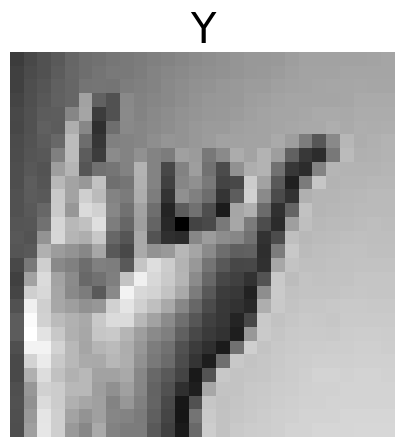

In [11]:
rnd_idx = random.choice(train_df.index.tolist())
image = train_df.iloc[rnd_idx].drop('label').values
label = train_df.iloc[rnd_idx]['label']
show(image, label)

In [12]:
IMG_HEIGHT = 28
IMG_WIDTH = 28
IMG_CHANNELS = 1

class AslDataset(Dataset):
    def __init__(self, base_df):
        x_df = base_df.copy()
        y_df = x_df.pop('label')
        x_df = x_df.values / 255
        x_df = x_df.reshape(-1, IMG_CHANNELS, IMG_WIDTH, IMG_HEIGHT)
        self.xs = torch.tensor(x_df).float().to(device)
        self.ys = torch.tensor(y_df).long().to(device)

    def __getitem__(self, idx):
        x = self.xs[idx]
        y = self.ys[idx]
        return x, y

    def __len__(self):
        return len(self.xs)

In [13]:
train_data = AslDataset(train_df)
val_data = AslDataset(val_df)
test_data = AslDataset(test_df)

In [14]:
batch_size = 32

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=True)

In [15]:
def get_batch_accuracy(output, y, N):
    pred = output.argmax(dim=1, keepdim=True)
    correct = pred.eq(y.view_as(pred)).sum().item()
    return correct / N

In [16]:
def train(_model, _train_loader, _val_loader, _criterion, _optimizer, _num_epochs):
    res = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
    }
    iterator = tqdm(range(epochs), desc="Training", unit="epoch")

    for _ in iterator:
        _model.train()
        train_loss = 0.0
        train_acc = 0.0
        for X_batch, y_batch in _train_loader:
            _optimizer.zero_grad()
            outputs = _model(X_batch)
            loss = _criterion(outputs, y_batch)
            loss.backward()
            _optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
            train_acc += get_batch_accuracy(outputs, y_batch, len(_train_loader.dataset))

        epoch_train_loss = train_loss / len(_train_loader.dataset)

        _model.eval()
        val_loss = 0.0
        val_acc = 0.0
        with torch.no_grad():
            for X_val, y_val in _val_loader:
                val_outputs = _model(X_val)
                val_loss += _criterion(val_outputs, y_val).item() * X_val.size(0)
                val_acc += get_batch_accuracy(val_outputs, y_val, len(_val_loader.dataset))

        epoch_val_loss = val_loss / len(_val_loader.dataset)

        iterator.set_postfix(
            train_loss=f"{epoch_train_loss:.4f}",
            train_acc=f"{train_acc:.4f}",
            val_loss=f"{epoch_val_loss:.4f}",
            val_acc=f"{val_acc:.4f}",
        )

        res['train_loss'].append(epoch_train_loss)
        res['train_acc'].append(train_acc)
        res['val_loss'].append(epoch_val_loss)
        res['val_acc'].append(val_acc)

    return res

In [17]:
def test(_model, _test_loader, _loss_function):
    _model.eval()
    test_loss = 0.0
    test_acc = 0.0
    with torch.no_grad():
        for x, y in _test_loader:
            output = _model(x)
            test_loss += _loss_function(output, y).item() * x.size(0)
            test_acc += get_batch_accuracy(output, y, len(_test_loader.dataset))

    return (test_loss / len(_test_loader.dataset)), test_acc

## Training the models

In [18]:
class ConvolutionalBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout_p):
        super().__init__()
        kernel_size = 3

        self.model = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size, stride=1, padding=1),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.MaxPool2d(2, stride=2)
        )

    def forward(self, x):
        return self.model(x)

In [19]:
model_cnn = nn.Sequential(
    ConvolutionalBlock(IMG_CHANNELS, 25, 0), # 25 x 14 x 14
    ConvolutionalBlock(25, 50, 0.2),  # 50 x 7 x 7
    ConvolutionalBlock(50, 75, 0),  # 75 x 3 x 3

    nn.Flatten(),
    nn.Linear(75 * 3 * 3, 512),
    nn.Dropout(.3),
    nn.ReLU(),

    nn.Linear(512, 24)
)

model_cnn = model_cnn.to(device)

In [20]:
epochs = 20
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model_cnn.parameters())

cnn_res = train(model_cnn, train_loader, val_loader, loss_function, optimizer, epochs)

Training: 100%|██████████| 20/20 [01:35<00:00,  4.76s/epoch, train_acc=0.9970, train_loss=0.0102, val_acc=0.9671, val_loss=0.1650]


In [21]:
cnn_test_loss, cnn_test_acc = test(model_cnn, test_loader, loss_function)

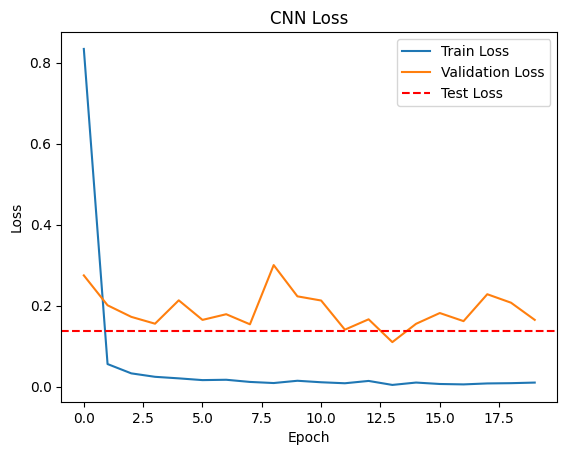

In [22]:
plt.plot(cnn_res['train_loss'], label='Train Loss')
plt.plot(cnn_res['val_loss'], label='Validation Loss')
plt.axhline(cnn_test_loss, label='Test Loss', linestyle='--', color='r')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Data Augmentation

In [23]:
trans = transforms.Compose([
    transforms.RandomResizedCrop((IMG_WIDTH, IMG_HEIGHT), scale=(.7, 1), ratio=(1, 1)),
])

In [24]:
def compare_images(_img, t):
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(F.to_pil_image(_img), cmap='gray')
    axes[0].set_title("Original Image")
    axes[0].axis('off')

    img_transformed = t(_img).cpu()
    axes[1].imshow(F.to_pil_image(img_transformed), cmap='gray')
    axes[1].set_title("Transformed Image")
    axes[1].axis('off')
    plt.show()

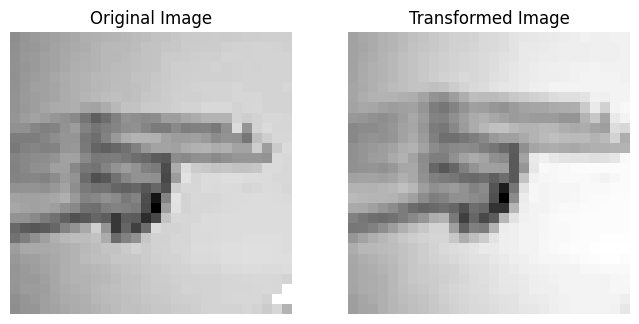

In [25]:
random_idx = random.randint(0, len(train_data) - 1)
img, _ = train_data[random_idx]
compare_images(img.cpu(), trans)

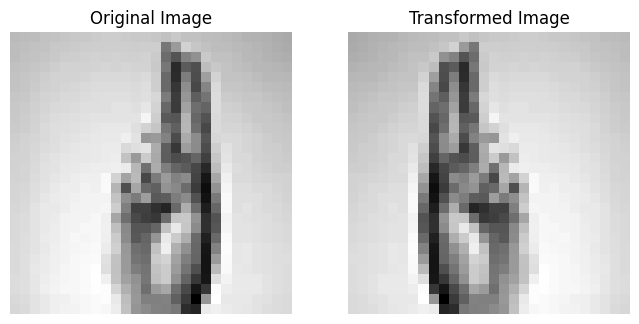

In [26]:
trans = transforms.Compose([
    transforms.RandomHorizontalFlip()
])

random_idx = random.randint(0, len(train_data) - 1)
img, _ = train_data[random_idx]
compare_images(img.cpu(), trans)

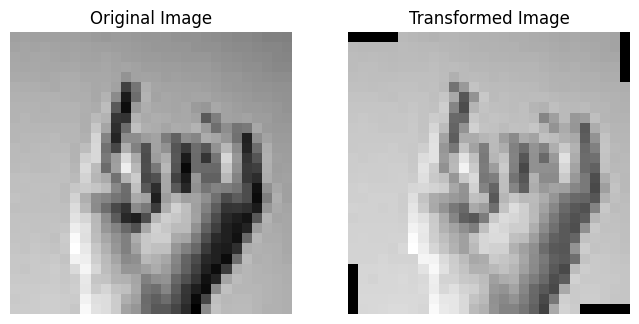

In [27]:
trans = transforms.Compose([
    transforms.RandomRotation(30)
])

random_idx = random.randint(0, len(train_data) - 1)
img, _ = train_data[random_idx]
compare_images(img.cpu(), trans)

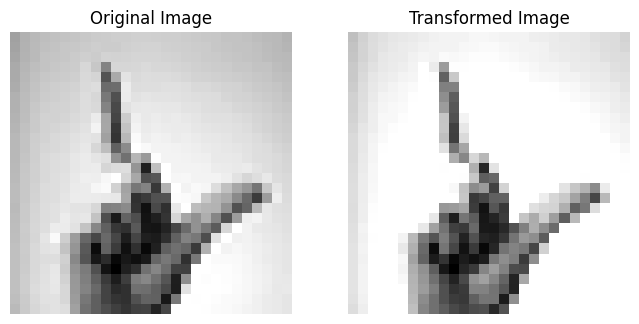

In [28]:
brightness = .2  # Change to be from 0 to 1
contrast = .5  # Change to be from 0 to 1

trans = transforms.Compose([
    transforms.ColorJitter(brightness=brightness, contrast=contrast)
])

random_idx = random.randint(0, len(train_data) - 1)
img, _ = train_data[random_idx]
compare_images(img.cpu(), trans)

## Training with augmentation

In [29]:
def train(_model, _train_loader, _val_loader, _criterion, _optimizer, _num_epochs, _transforms=None):
    res = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
    }
    iterator = tqdm(range(epochs), desc="Training", unit="epoch")

    for _ in iterator:
        _model.train()
        train_loss = 0.0
        train_acc = 0.0
        for X_batch, y_batch in _train_loader:
            _optimizer.zero_grad()
            _x = X_batch
            if _transforms is not None:
                _x = _transforms(_x)
            outputs = _model(_x)
            loss = _criterion(outputs, y_batch)
            loss.backward()
            _optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
            train_acc += get_batch_accuracy(outputs, y_batch, len(_train_loader.dataset))

        epoch_train_loss = train_loss / len(_train_loader.dataset)

        _model.eval()
        val_loss = 0.0
        val_acc = 0.0
        with torch.no_grad():
            for X_val, y_val in _val_loader:
                val_outputs = _model(X_val)
                val_loss += _criterion(val_outputs, y_val).item() * X_val.size(0)
                val_acc += get_batch_accuracy(val_outputs, y_val, len(_val_loader.dataset))

        epoch_val_loss = val_loss / len(_val_loader.dataset)

        iterator.set_postfix(
            train_loss=f"{epoch_train_loss:.4f}",
            train_acc=f"{train_acc:.4f}",
            val_loss=f"{epoch_val_loss:.4f}",
            val_acc=f"{val_acc:.4f}",
        )

        res['train_loss'].append(epoch_train_loss)
        res['train_acc'].append(train_acc)
        res['val_loss'].append(epoch_val_loss)
        res['val_acc'].append(val_acc)

    return res

In [30]:
random_transforms = transforms.Compose([
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop((IMG_WIDTH, IMG_HEIGHT), scale=(.9, 1), ratio=(1, 1)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=.2, contrast=.5)
])

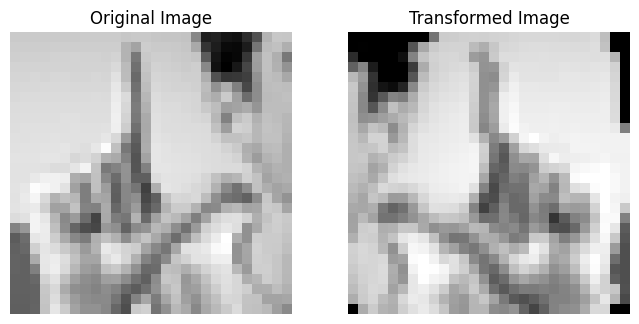

In [31]:
random_idx = random.randint(0, len(train_data) - 1)
img, _ = train_data[random_idx]
compare_images(img.cpu(), random_transforms)

In [32]:
model_cnn_aug = nn.Sequential(
    ConvolutionalBlock(IMG_CHANNELS, 25, 0), # 25 x 14 x 14
    ConvolutionalBlock(25, 50, 0.2),  # 50 x 7 x 7
    ConvolutionalBlock(50, 75, 0),  # 75 x 3 x 3

    nn.Flatten(),
    nn.Linear(75 * 3 * 3, 512),
    nn.Dropout(.3),
    nn.ReLU(),

    nn.Linear(512, 24)
)

model_cnn_aug = model_cnn_aug.to(device)

In [33]:
epochs = 20
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model_cnn_aug.parameters())

cnn_aug_res = train(model_cnn_aug, train_loader, val_loader, loss_function, optimizer, epochs, random_transforms)

Training: 100%|██████████| 20/20 [02:16<00:00,  6.80s/epoch, train_acc=0.9799, train_loss=0.0625, val_acc=0.9529, val_loss=0.1264]


In [34]:
cnn_aug_test_loss, cnn_aug_test_acc = test(model_cnn_aug, test_loader, loss_function)

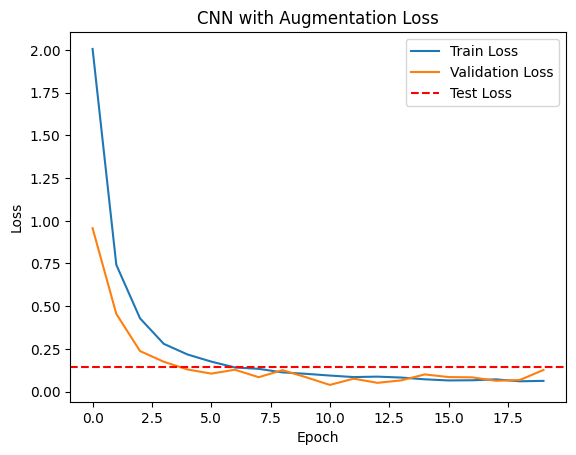

In [35]:
plt.plot(cnn_aug_res['train_loss'], label='Train Loss')
plt.plot(cnn_aug_res['val_loss'], label='Validation Loss')
plt.axhline(cnn_aug_test_loss, label='Test Loss', linestyle='--', color='r')
plt.legend()
plt.title('CNN with Augmentation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Reflection section

What impact did data augmentation had on the model performance? Tuvo un impacto positivo, ya que dedujo el overfitting que habia en la CNN normal, aunque el training loss bajo mas rapido que con augmentation, el validation loss en la normal se mantiene alto e inestable, con augmentation ambas bajan de manera gradual y no hay casi nada de overfitting

Re-run training with a smaller subset of train data (both with augmentation and without it)

In [37]:
train_df = pd.read_csv(data_base_path + "train.csv").sample(frac=0.2, random_state=42).reset_index(drop=True)
train_data = AslDataset(train_df)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)

In [38]:
model_small = model_cnn
optimizer = Adam(model_small.parameters())

res_small = train(
    model_small,
    train_loader,  
    val_loader,
    loss_function,
    optimizer,
    epochs
)

Training: 100%|██████████| 20/20 [00:22<00:00,  1.15s/epoch, train_acc=0.9924, train_loss=0.0320, val_acc=0.9504, val_loss=0.2871]


In [43]:
cnn_test_loss, cnn_test_acc = test(model_small, test_loader, loss_function)

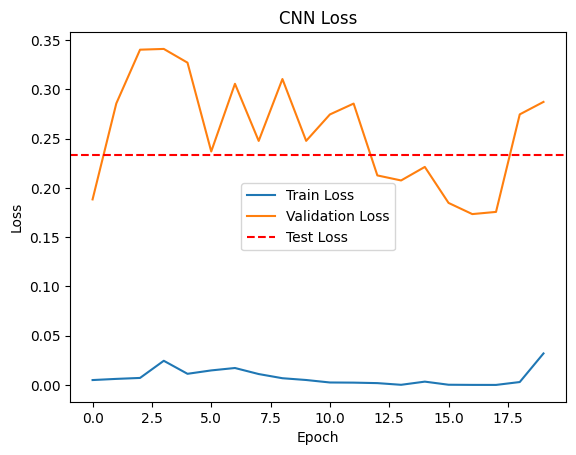

In [44]:
plt.plot(res_small['train_loss'], label='Train Loss')
plt.plot(res_small['val_loss'], label='Validation Loss')
plt.axhline(cnn_test_loss, label='Test Loss', linestyle='--', color='r')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [40]:
model_small_aug = model_cnn_aug
optimizer = Adam(model_small_aug.parameters())

res_small_aug = train(
    model_small_aug,
    train_loader, 
    val_loader,
    loss_function,
    optimizer,
    epochs,
    random_transforms
)

Training: 100%|██████████| 20/20 [00:30<00:00,  1.52s/epoch, train_acc=0.9838, train_loss=0.0481, val_acc=0.9833, val_loss=0.0510]


In [45]:
cnn_aug_test_loss, cnn_aug_test_acc = test(model_small_aug, test_loader, loss_function)

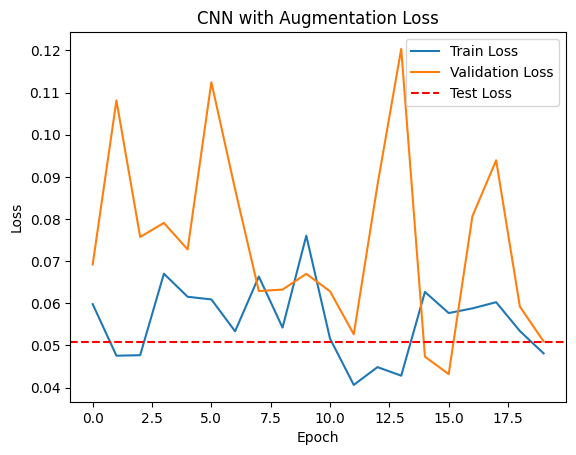

In [46]:
plt.plot(res_small_aug['train_loss'], label='Train Loss')
plt.plot(res_small_aug['val_loss'], label='Validation Loss')
plt.axhline(cnn_aug_test_loss, label='Test Loss', linestyle='--', color='r')
plt.legend()
plt.title('CNN with Augmentation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Re-train the model using a different transformation pipeline for augmentation

In [55]:
new_transforms = transforms.Compose([
    transforms.RandomInvert(0.5),
    transforms.RandomVerticalFlip(0.5),
    transforms.RandomSolarize(0.5),
])

In [56]:
res_new = train(
    model_small_aug,
    train_loader,
    val_loader,
    loss_function,
    optimizer,
    epochs,
    new_transforms
)

Training: 100%|██████████| 20/20 [00:23<00:00,  1.16s/epoch, train_acc=0.9661, train_loss=0.1001, val_acc=0.9576, val_loss=0.1512]


In [57]:
new_test_loss, new_test_acc = test(model_small_aug, test_loader, loss_function)

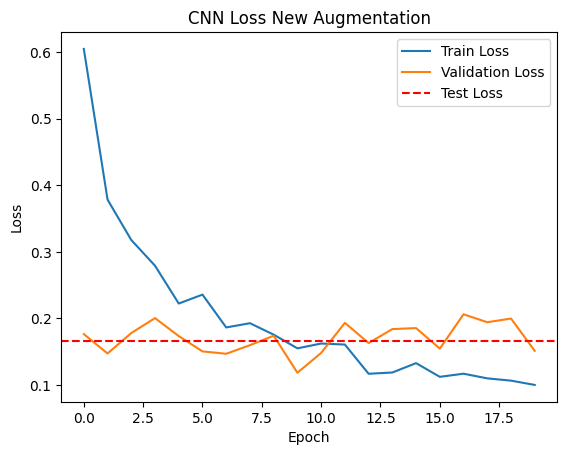

In [58]:
plt.plot(res_new['train_loss'], label='Train Loss')
plt.plot(res_new['val_loss'], label='Validation Loss')
plt.axhline(new_test_loss, label='Test Loss', linestyle='--', color='r')

plt.title('CNN Loss New Augmentation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Write down your final remarks

Usando un subset mas chico hizo que hubiera mucho mas overfitting, pero todavia se nota que hay un mejor performance con augmentation ya que se mantienen mas cercanos las losses con augmentation. Usando diferentes tranforms, cambio mucho el desempeño del modelo, aumento el validation loss y hay bastante overfitting, puede ser que los tranforms que use no son muy adecuados para el ASL porque cambia mucho la imagen.